## Build the dataset

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, mean_squared_error, r2_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(42)
n = 1000








In [16]:
df = pd.DataFrame({
    'study_hours'   : np.random.normal(6, 2, n).clip(0, 12),
    'sleep_hours'   : np.random.normal(7, 1.5, n).clip(3, 10),
    'attendance_pct': np.random.normal(75, 15, n).clip(0, 100),
    'prev_score'    : np.random.normal(65, 15, n).clip(0, 100),
    'stress_level'  : np.random.randint(1, 10, n).astype(float),
    'exercise_days' : np.random.randint(0, 7, n).astype(float),
})

score = (
    df['study_hours']    * 4.0 +
    df['attendance_pct'] * 0.3 +
    df['prev_score']     * 0.4 +
    df['sleep_hours']    * 1.5 +
    np.random.normal(0, 5, n)
)

df['result']       = (score > score.median()).astype(int)
df['actual_score'] = score
df

,study_hours,sleep_hours,attendance_pct,prev_score,stress_level,exercise_days,result,actual_score
0,4.555400,8.426916,69.911929,68.038978,7.0,3.0,0,73.685376
1,4.842698,6.508277,79.379488,32.905587,1.0,4.0,0,67.291718
2,4.479615,6.224904,81.684653,71.587556,1.0,5.0,1,89.102315
3,4.266150,6.650296,84.318841,74.658695,3.0,0.0,0,80.645403
4,7.386992,9.171787,61.827974,38.028825,2.0,4.0,0,76.370362
...,...,...,...,...,...,...,...,...
995,7.003789,6.513287,97.948252,42.406777,7.0,0.0,1,83.170257
996,10.198499,5.752782,67.481565,50.337870,5.0,6.0,1,93.430078
997,4.587553,7.643510,59.688897,70.042298,3.0,5.0,0,69.691246
998,6.137524,8.780340,57.973209,57.063310,3.0,3.0,0,78.050118


In [18]:
X      = df.drop(['result', 'actual_score'], axis=1)
y_clf  = df['result']
y_reg  = df['actual_score']

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

## Classification

In [19]:
gb_clf = GradientBoostingClassifier(
    n_estimators  = 100,
    # ↑ number of boosting rounds (trees)
    #   more = better but slower + overfit risk

    learning_rate = 0.1,
    # ↑ shrinks each tree's contribution
    #   smaller = more conservative, needs more trees
    #   trade-off: learning_rate × n_estimators ≈ constant

    max_depth     = 3,
    # ↑ depth of each tree
    #   shallow trees (2-5) are recommended
    #   deeper trees = more complex = overfit faster

    subsample     = 1.0,
    # ↑ fraction of samples used per tree
    #   1.0 = use all samples (standard GB)
    #   <1.0 = stochastic GB (adds randomness, often better)
    #   typical: 0.5 to 0.8

    max_features  = None,
    # ↑ features considered at each split
    #   None = all features
    #   'sqrt' = random subset like Random Forest
    #   adds randomness, reduces overfitting

    min_samples_split = 2,
    # ↑ min samples to split a node
    #   increase to prevent overfitting

    random_state  = 42,
    verbose       = 0
)

gb_clf.fit(X_train, y_train)
y_pred     = gb_clf.predict(X_test)
y_prob     = gb_clf.predict_proba(X_test)[:, 1]

print("Classification Results:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

Classification Results:
  Accuracy : 0.8300
  ROC-AUC  : 0.9219
              precision    recall  f1-score   support

        Fail       0.81      0.83      0.82        94
        Pass       0.85      0.83      0.84       106

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



## Regression

In [20]:
gb_reg = GradientBoostingRegressor(
    n_estimators  = 100,
    learning_rate = 0.1,
    max_depth     = 3,
    subsample     = 0.8,
    random_state  = 42
)

gb_reg.fit(X_train_r, y_train_r)
y_pred_r = gb_reg.predict(X_test_r)

print("Regression Results:")
print(f"  R² Score : {r2_score(y_test_r, y_pred_r):.4f}")
print(f"  RMSE     : {mean_squared_error(y_test_r, y_pred_r)**0.5:.4f}")

Regression Results:
  R² Score : 0.8038
  RMSE     : 5.1814


## Watch Training Progress — Staged Predictions

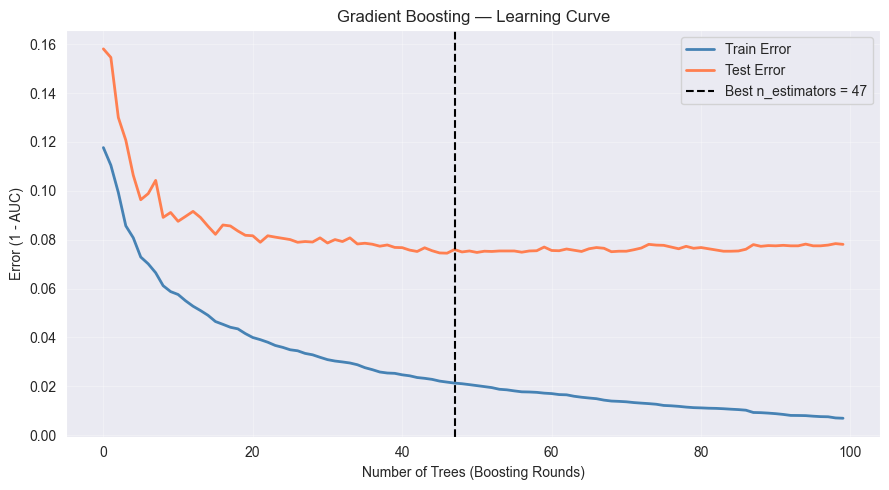

Optimal number of trees: 47


In [22]:
# staged_predict gives prediction after each boosting round
train_errors = []
test_errors  = []

for y_pred_staged in gb_clf.staged_predict_proba(X_train):
    train_errors.append(1 - roc_auc_score(y_train, y_pred_staged[:, 1]))

for y_pred_staged in gb_clf.staged_predict_proba(X_test):
    test_errors.append(1 - roc_auc_score(y_test, y_pred_staged[:, 1]))

plt.figure(figsize=(9, 5))
plt.plot(train_errors, color='steelblue', linewidth=2, label='Train Error')
plt.plot(test_errors,  color='coral', linewidth=2, label='Test Error')

# Mark optimal number of trees
best_n = np.argmin(test_errors) + 1
plt.axvline(x=best_n, color='black', linestyle='--', label=f'Best n_estimators = {best_n}')

plt.xlabel("Number of Trees (Boosting Rounds)")
plt.ylabel("Error (1 - AUC)")
plt.title("Gradient Boosting — Learning Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal number of trees: {best_n}")
# Use this to set n_estimators in final model

## Feature Importance


Feature Importances:
study_hours       0.4500
prev_score        0.2609
attendance_pct    0.1948
sleep_hours       0.0752
exercise_days     0.0141
stress_level      0.0050
dtype: float64


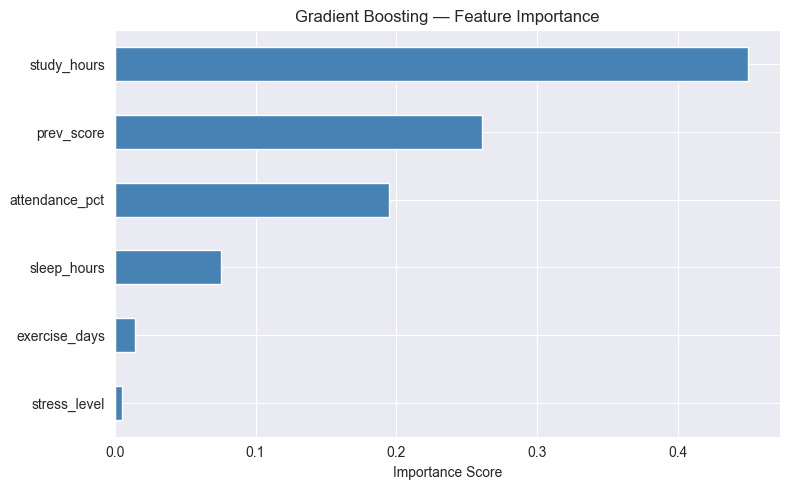

In [23]:
importances = pd.Series(gb_clf.feature_importances_, index=feature_names).sort_values(ascending=False)

print("\nFeature Importances:")
print(importances.round(4))

importances.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title("Gradient Boosting — Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [2, 3, 4],
    'subsample'     : [0.8, 1.0],
    'max_features'  : [None, 'sqrt']
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv      = 5,
    scoring = 'roc_auc',
    n_jobs  = -1,
    verbose = 1
)

grid.fit(X_train, y_train)
print("\nBest Parameters:", grid.best_params_)
print("Best CV AUC    :", grid.best_score_.round(4))
print("Test AUC       :",
      roc_auc_score(y_test,
      grid.predict_proba(X_test)[:, 1]))

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters: {'learning_rate': 0.2, 'max_depth': 2, 'max_features': 'sqrt', 'n_estimators': 100, 'subsample': 1.0}
Best CV AUC    : 0.9414
Test AUC       : 0.9422769107643056
